# Mini Project 1: YouTube Livestream Chat Analysis

**Your name:** Jared Ren  
**Dataset:** YouTube livestream chat from four LEC (League of Legends EMEA Championship) tournament VODs  
**Date:** May 2026

This notebook tells the story of a pandas analysis and Plotly visualizations on collected chat replay data. Work through the sections in order.


In [1]:
!pip install jupyter plotly kaleido pandas


In [2]:
# numpy handles math operations like rounding and ceiling calculations
import numpy as np
# pandas is the main tool for loading and working with the chat data tables
import pandas as pd
# plotly.express is used to build the interactive charts
import plotly.express as px
# Path makes it easy to reference file and folder locations without hardcoding strings
from pathlib import Path

print("Imports ready.")


Imports ready.


---

## Section 1: Overview

**Dataset:** YouTube livestream chat replay exports, one row per chat message, with UTC `timestamp`, stable `author_channel_id`, message text, `message_type`, and `video_offset_sec` from stream start. Collected with **yt-dlp** via `collect_vod_chat.py` (see `Week 5/A5/` in the course repo).

**Provenance (reconstructed from files in this folder, not from live YouTube metadata):**  
Four CSVs in `chat_regular/` use filenames `chat_<VIDEO_ID>.csv`. The video ID is the suffix after `chat_`. Canonical watch URLs are built as `https://www.youtube.com/watch?v=<ID>`. **Video titles and channel names were not verified offline.** Only IDs and message timestamps come from these files.

| File | Video ID | Reconstructed URL |
|------|----------|-------------------|
| `chat__dE6Hddb8do.csv` | `_dE6Hddb8do` | https://www.youtube.com/watch?v=_dE6Hddb8do |
| `chat_mPI1-aute0w.csv` | `mPI1-aute0w` | https://www.youtube.com/watch?v=mPI1-aute0w |
| `chat_oxUSw1N9i3k.csv` | `oxUSw1N9i3k` | https://www.youtube.com/watch?v=oxUSw1N9i3k |
| `chat_vUmNslJBba0.csv` | `vUmNslJBba0` | https://www.youtube.com/watch?v=vUmNslJBba0 |

**Observed message timestamp window (inferred from `timestamp` columns, not a separate capture log):**  
- Per file (UTC): `_dE6Hddb8do` 2026-05-02 13:46:52 → 19:24:35; `mPI1-aute0w` 2026-05-03 13:59:23 → 18:52:35; `oxUSw1N9i3k` 2026-05-04 13:46:35 → 20:33:43; `vUmNslJBba0` 2026-04-26 13:48:43 → 21:33:13.  
- **Across all four files:** earliest message **2026-04-26 13:48:43 UTC**, latest **2026-05-04 20:33:43 UTC**.


**Why this dataset:**

> I picked YouTube livestream chat because I wanted to look at how people interact with each other digitally in real time and how they react to content as it happens on screen. Gaming livestreams sit at a useful intersection for this: chat is almost always enabled, there are usually many active chatters at once, and the language is dense with jargon. Some of it is community-oriented, (gaming culture broadly), some game-specific, some region-specific. Capturing that mix as a starting project felt closer to how communication actually shows up in these spaces than a cleaner conversational dataset would.

**How this plan was adjusted (original vs collected data):**  
The first plan included a third question about **Super Chat** rates in high- vs low-volume chat periods. After export, this pull has **only** `textMessageEvent` rows and **`super_chat_amount` is entirely empty** on every row , paid messages are not present in these files. **Question 3 was pivoted** to participation shape: unique authors per 5-minute bin and share of lines from the stream-wide top 10% of posters, compared between quieter and busier bins (median split on bin volume, same binning as Q1). See Section 5 for the documented pivot reasoning.

**Three analytical questions:**

1. How does chat message volume (messages per minute) change over the course of a single livestream, and at what timestamps do the highest-volume bursts occur? (5-minute binning and frequency counts in pandas.)
2. What share of total messages in a stream are contributed by the top 10% of most active users, and how concentrated is participation across the chat audience? (`value_counts` and cumulative distribution on `author_channel_id`.)
3. How does participation **breadth and dominance** differ between **high-** and **low-volume** 5-minute windows on the primary stream , average **unique authors** per bin and **share of messages** from authors in the stream’s global top 10% by message count? (Pivoted from Super Chat; median split on bin volume.)

**What a practitioner would do with these findings:**

> Two roles would find this useful. Video editors producing summary cuts of long broadcasts could use volume-burst windows to locate moments worth pulling without rewatching hours of footage. If chat rate jumped to 47.8 messages per minute against a 15.8 baseline, something on screen was likely worth surfacing. Engagement analysts could use participation-shape metrics (top-10% concentration, breadth across busy vs. quiet windows) as a complement to YouTube's native analytics, which report aggregate views and likes but don't expose who is actually doing the talking. Whether those patterns generalize to co-stream venues is a separate question (see Limitations).


---

## Section 2: Data Profile

Load all four chat exports, inspect structure, types, and missing values. Each code cell is followed by a one-sentence factual read of that output.

**How the four streams are used in this notebook:**  
All four CSVs are **loaded and concatenated** (20,985 rows) so each file keeps a `stream_id` tag. **Questions 1–3 and all three charts use only the primary stream**, `vUmNslJBba0`,, selected programmatically as the VOD with the longest `video_offset_sec` (same rule as A5 `chat_analysis.py`). The other three files remain in `chat_regular/` as part of the same collection artifact; they are **not** pooled into the Q1–Q3 metrics or charts in this notebook.


In [3]:
# Load chat exports from chat_regular/ next to this notebook

# Set the base directory to wherever this notebook is being run from
base_dir = Path.cwd()
chat_dir = base_dir / "chat_regular"

# Look for CSV files in the chat_regular subfolder first, then fall back to the notebook folder
if any(chat_dir.glob("chat*.csv")):
    chat_files = sorted(chat_dir.glob("chat*.csv"))
else:
    chat_files = sorted(base_dir.glob("chat*.csv"))

# Stop early with a clear message if no files are found
if not chat_files:
    raise FileNotFoundError(
        f"No chat*.csv in {chat_dir} or {base_dir}. "
        "Add files to chat_regular/ or the notebook folder."
    )

# If there is only one file, load it directly
# If there are multiple files, stack them all into one table and keep track of which row came from which file
if len(chat_files) == 1:
    df = pd.read_csv(chat_files[0])
    df["source_file"] = chat_files[0].name
else:
    # assign() adds the source_file column before stacking so each row knows which stream it belongs to
    df = pd.concat(
        [pd.read_csv(path).assign(source_file=path.name) for path in chat_files],
        ignore_index=True,
    )

# Pull the YouTube video ID out of the filename
# e.g. "chat_vUmNslJBba0.csv" becomes "vUmNslJBba0"
df["stream_id"] = (
    df["source_file"].str.removesuffix(".csv").str.removeprefix("chat_")
)

# Pick the primary stream: whichever VOD has the largest video_offset_sec value (the longest stream)
PRIMARY_STREAM_ID = df.groupby("stream_id")["video_offset_sec"].max().idxmax()

print(f"Loaded {len(chat_files)} file(s):", [p.name for p in chat_files])
print("Primary stream for Q1-Q3:", PRIMARY_STREAM_ID)
print(df.shape)
print(df.groupby("stream_id").size())
df.head()


Loaded 4 file(s): ['chat__dE6Hddb8do.csv', 'chat_mPI1-aute0w.csv', 'chat_oxUSw1N9i3k.csv', 'chat_vUmNslJBba0.csv']
Primary stream for Q1–Q3: vUmNslJBba0
(20985, 11)
stream_id
_dE6Hddb8do    3438
mPI1-aute0w    3625
oxUSw1N9i3k    5951
vUmNslJBba0    7971
dtype: int64


,timestamp,author_channel_id,display_name,message_text,message_sentiment,message_summary,message_type,super_chat_amount,video_offset_sec,source_file,stream_id
0,2026-05-02T13:46:52.641Z,UCRW-u9pyKpypEmjKKmvO_6A,@EMPtraxis,Looks like this is gonna be target practice fo...,neutral,looks like this,textMessageEvent,NaN,65.444,chat__dE6Hddb8do.csv,_dE6Hddb8do
1,2026-05-02T13:48:56.241Z,UCUaoe_b7_H7S1hN25er99eA,@georathor8814,if fnc goes 0-2 this week its byebye playoffs ...,questioning,question,textMessageEvent,NaN,188.985,chat__dE6Hddb8do.csv,_dE6Hddb8do
2,2026-05-02T13:49:34.666Z,UCYw246cyLEB3GprEEUBs2rw,@KILLERMIKE-1,wsp,neutral,wsp,textMessageEvent,NaN,227.565,chat__dE6Hddb8do.csv,_dE6Hddb8do
3,2026-05-02T13:50:26.812Z,UCTJYD_exfZg8UVjn80ROLqQ,@limeyman.,i like league saturdays,neutral,i like league,textMessageEvent,NaN,279.644,chat__dE6Hddb8do.csv,_dE6Hddb8do
4,2026-05-02T13:50:49.903Z,UCTJYD_exfZg8UVjn80ROLqQ,@limeyman.,lck into lpl into lec into lcs :D,neutral,lck into lpl,textMessageEvent,NaN,302.712,chat__dE6Hddb8do.csv,_dE6Hddb8do


In [4]:
# Build a provenance table for each CSV file
# The YouTube video ID is embedded in the filename, so we reconstruct the watch URL from it
# We also read the timestamp column to find the earliest and latest message in each file

rows = []
for path in sorted(chat_dir.glob("chat_*.csv")):
    # Strip "chat_" prefix and ".csv" suffix to isolate the raw video ID
    vid = path.stem.removeprefix("chat_")
    chunk = pd.read_csv(path, usecols=["timestamp"])
    ts = pd.to_datetime(chunk["timestamp"], utc=True, errors="coerce")
    rows.append(
        {
            "file": path.name,
            "video_id": vid,
            "watch_url": f"https://www.youtube.com/watch?v={vid}",
            "rows": len(chunk),
            "min_timestamp_utc": ts.min(),
            "max_timestamp_utc": ts.max(),
        }
    )
prov = pd.DataFrame(rows)
print("URLs reconstructed from filenames; titles/channels not verified offline.\n")
display(prov)
print(
    f"\nCombined window: {prov['min_timestamp_utc'].min()} -> {prov['max_timestamp_utc'].max()} (UTC)"
)


URLs reconstructed from filenames; titles/channels not verified offline.



,file,video_id,watch_url,rows,min_timestamp_utc,max_timestamp_utc
0,chat__dE6Hddb8do.csv,_dE6Hddb8do,https://www.youtube.com/watch?v=_dE6Hddb8do,3438,2026-05-02 13:46:52.641000+00:00,2026-05-02 19:24:35.903000+00:00
1,chat_mPI1-aute0w.csv,mPI1-aute0w,https://www.youtube.com/watch?v=mPI1-aute0w,3625,2026-05-03 13:59:23.746000+00:00,2026-05-03 18:52:35.231000+00:00
2,chat_oxUSw1N9i3k.csv,oxUSw1N9i3k,https://www.youtube.com/watch?v=oxUSw1N9i3k,5951,2026-05-04 13:46:35.477000+00:00,2026-05-04 20:33:43.859000+00:00
3,chat_vUmNslJBba0.csv,vUmNslJBba0,https://www.youtube.com/watch?v=vUmNslJBba0,7971,2026-04-26 13:48:43.982000+00:00,2026-04-26 21:33:13.520000+00:00



Combined window: 2026-04-26 13:48:43.982000+00:00 → 2026-05-04 20:33:43.859000+00:00 (UTC)


In [ ]:
df.head()

**`df.head()`: Interpretation**  
The preview shows five rows of a table with **11 columns**: each row is one chat message with string `timestamp`, `author_channel_id`, `display_name`, `message_text`, sentiment fields, `message_type`, float `super_chat_amount` (shown as NaN in the sample), float `video_offset_sec`, plus derived `source_file` and `stream_id` identifying which of the four VOD exports the row came from.

In [5]:
# df.info() shows column names, data types, and how many non-null values each column has
# This is a quick way to catch missing data and confirm columns loaded as the expected type
df.info()

# Also check what message types are present and whether any paid Super Chat messages exist
print("\nmessage_type counts:")
print(df["message_type"].value_counts(dropna=False))
print("\nRows with non-null super_chat_amount:", df["super_chat_amount"].notna().sum())


<class 'pandas.DataFrame'>
RangeIndex: 20985 entries, 0 to 20984
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   timestamp          20985 non-null  str    
 1   author_channel_id  20985 non-null  str    
 2   display_name       20985 non-null  str    
 3   message_text       20842 non-null  str    
 4   message_sentiment  20985 non-null  str    
 5   message_summary    20985 non-null  str    
 6   message_type       20985 non-null  str    
 7   super_chat_amount  0 non-null      float64
 8   video_offset_sec   20985 non-null  float64
 9   source_file        20985 non-null  str    
 10  stream_id          20985 non-null  str    
dtypes: float64(2), str(9)
memory usage: 1.8 MB

message_type counts:
message_type
textMessageEvent    20985
Name: count, dtype: int64

Rows with non-null super_chat_amount: 0


**`df.info()`: Interpretation**  
`info()` reports **20,985 rows** and **11 columns** with **no null entries** in `timestamp`, `author_channel_id`, or `video_offset_sec`; `message_text` has **143** nulls out of 20,985; `super_chat_amount` has **0** non-null values (column present as float64 but entirely empty). `message_type` counts show a single category, **`textMessageEvent` (20,985)**, with zero `superChatEvent` rows in this combined export.

In [6]:
# df.describe() gives summary statistics for numeric columns: count, mean, min, max, quartiles
# Useful for spotting unexpected ranges or outliers in columns like video_offset_sec
df.describe()


,super_chat_amount,video_offset_sec
count,0.0,20985.000000
mean,NaN,13783.410140
std,NaN,6325.694667
min,NaN,48.255000
25%,NaN,8221.753000
50%,NaN,13555.833000
75%,NaN,18621.880000
max,NaN,28022.668000


**`df.describe()`: Interpretation**  
`describe()` only summarizes numeric columns: `super_chat_amount` has **count 0** (no usable values); `video_offset_sec` has **20,985** non-null values ranging from about **48.3** to **28,022.7** seconds with mean about **13,783.4** seconds (~3.8 hours average offset across the combined file, dominated by the longest streams).

In [7]:
# Count the number of missing/blank values in each column
# Columns with many nulls may need special handling before they can be used in the analysis
df.isnull().sum()


timestamp                0
author_channel_id        0
display_name             0
message_text           143
message_sentiment        0
message_summary          0
message_type             0
super_chat_amount    20985
video_offset_sec         0
source_file              0
stream_id                0
dtype: int64

**`df.isnull().sum()`: Interpretation**  
Null counts are **0** for `timestamp`, `author_channel_id`, `display_name`, `message_sentiment`, `message_summary`, `message_type`, `video_offset_sec`, `source_file`, and `stream_id`; **143** for `message_text`; **20,985** for `super_chat_amount` (every row).  

The 143 nulls in `message_text` most likely represent messages whose text didn't survive the export , emoji-only messages, symbols, or formatting that didn't parse cleanly. They don't affect Q1, Q2, or Q3: Q1 counts messages by time bin and only needs `video_offset_sec`; Q2 and Q3 are author-level and only need `author_channel_id`, which is complete. The nulls would still count toward overall engagement volume , they're real messages someone sent , so I left them in rather than filter.


**Profile summary (combined load):**  
- **Shape:** **20,985** rows × **11** columns after concatenating four `chat_regular/` CSVs and adding `source_file` / `stream_id`.  
- **Per stream (`stream_id`):** `_dE6Hddb8do` **3,438**; `mPI1-aute0w` **3,625**; `oxUSw1N9i3k` **5,951**; `vUmNslJBba0` **7,971**.  
- **Analysis scope:** Q1–Q3 and Section 3 charts use **only** `vUmNslJBba0` (**7,971** rows) as the primary stream; the other three streams are loaded for provenance and consistency with the collection pipeline but are excluded from those computations.  
- **`author_channel_id`:** **0** nulls in the combined frame.  
- **`super_chat_amount` / `message_type`:** no populated Super Chat values; only `textMessageEvent` in this pull (motivates the Q3 pivot in Section 5).

---

## Section 3: Analysis

Pandas analysis for each research question, then visualizations (three charts) with static PNG exports to `images/`.


**Question 1:** How does chat message volume (messages per minute) change over the course of a single livestream, and at what timestamps do the highest-volume bursts occur?


In [8]:
# Q1 analysis: how does chat volume change over time during the stream?
# We cut the stream into 5-minute windows and count messages in each one

# Filter down to just the primary stream
primary = df[df["stream_id"] == PRIMARY_STREAM_ID].copy()

# Round each message's offset (seconds from stream start) down to the nearest 5-minute mark
# e.g. a message at 1,847 seconds -> bin starting at 1,800 seconds (minute 30)
primary["offset_min_bin_5"] = (primary["video_offset_sec"] // 300) * 5
primary["timestamp"] = pd.to_datetime(primary["timestamp"], utc=True, errors="coerce")
_bad_ts = int(primary["timestamp"].isna().sum())
if _bad_ts:
    print(f"Warning: {_bad_ts} row(s) could not parse as timestamps (coerced to NaT).")

# Count messages in each 5-minute window
bin_counts = (
    primary.groupby("offset_min_bin_5", as_index=False)
    .size()
    .rename(columns={"size": "messages_in_bin"})
)
# Divide bin count by 5 to get messages per minute (makes windows comparable regardless of length)
bin_counts["messages_per_min"] = bin_counts["messages_in_bin"] / 5.0

# Also grab the real UTC timestamps of the first and last message in each bin for reference
ts_bounds = primary.groupby("offset_min_bin_5")["timestamp"].agg(
    first_ts="min", last_ts="max"
).reset_index()

q1_summary = bin_counts.merge(ts_bounds, on="offset_min_bin_5", how="left")
median_mpm = bin_counts["messages_per_min"].median()
print(f"Primary stream: {PRIMARY_STREAM_ID}  |  messages: {len(primary):,}")
print(f"Median messages/min (5-min bins): {median_mpm:.1f}")
print("\nTop 5 burst windows (by messages/min):")
top5 = q1_summary.nlargest(5, "messages_per_min")[
    ["offset_min_bin_5", "messages_in_bin", "messages_per_min", "first_ts", "last_ts"]
]
print(top5.to_string(index=False))


Primary stream: vUmNslJBba0  |  messages: 7,971
Median messages/min (5-min bins): 15.8

Top 5 burst windows (by messages/min):
 offset_min_bin_5  messages_in_bin  messages_per_min                         first_ts                          last_ts
            385.0              239              47.8 2026-04-26 20:11:10.939000+00:00 2026-04-26 20:16:10.718000+00:00
            320.0              209              41.8 2026-04-26 19:06:12.394000+00:00 2026-04-26 19:11:04.683000+00:00
            370.0              198              39.6 2026-04-26 19:56:14.165000+00:00 2026-04-26 20:01:10.564000+00:00
            445.0              190              38.0 2026-04-26 21:11:11.054000+00:00 2026-04-26 21:16:08.956000+00:00
            250.0              176              35.2 2026-04-26 17:56:11.552000+00:00 2026-04-26 18:01:08.728000+00:00


**Q1: Factual read (primary stream `vUmNslJBba0`, 7,971 messages):**  
5-minute bins yield a median rate of **15.8** messages per minute; the top five burst windows run from about **35.2** to **47.8** messages per minute, with the highest bin at offset minute **385** (**239** messages in the 5-minute window). The printed `first_ts` / `last_ts` values map those bins to UTC wall-clock times only.

Message rate on the primary stream is bursty rather than flat. The peak window at minute 385 reaches 47.8 messages per minute against a stream-wide median of 15.8, roughly three times baseline (239 messages in that 5-minute bin). The chart argues that engagement on this VOD is concentrated in short windows an editor could locate without rewatching the full broadcast. It does not support claims about specific in-game events , there's no event log paired with these chat timestamps, so it supports "look here" but not "this happened because X."


**Question 2:** What share of total messages in a stream are contributed by the top 10% of most active users, and how concentrated is participation across the chat audience?


In [9]:
# Q2 analysis: how concentrated is chat activity across authors?
# We rank every author by total messages sent and calculate what share of chat the top 10% account for

# Filter to primary stream, then remove rows where the author ID is missing
primary_msgs = df[df["stream_id"] == PRIMARY_STREAM_ID]
_dropped_author = int(primary_msgs["author_channel_id"].isna().sum())
primary_msgs = primary_msgs.dropna(subset=["author_channel_id"])
if _dropped_author:
    print(
        f"Warning: dropped {_dropped_author} row(s) with missing author_channel_id "
        "before author-based counts."
    )

# Count how many messages each unique author sent (sorted from most to least active)
counts = primary_msgs["author_channel_id"].value_counts()
n_users = counts.size
total_msgs = counts.sum()

# Find the top 10% of authors by message count (using ceiling so we always include at least one)
k_top10 = max(1, int(np.ceil(0.10 * n_users)))
msgs_from_top10pct = counts.head(k_top10).sum()
share_top10 = msgs_from_top10pct / total_msgs

print(f"Primary stream: {PRIMARY_STREAM_ID}")
print(f"Unique authors: {n_users:,}  |  Total messages: {total_msgs:,}")
print(f"Top 10% of users = {k_top10} users (by message rank)")
print(f"Share of all messages from those users: {100 * share_top10:.1f}%")

# Build a cumulative distribution to see how much of total chat the top X% of authors account for
ranked = counts.sort_values(ascending=False).reset_index()
ranked.columns = ["author_channel_id", "messages"]
ranked["cum_msgs"] = ranked["messages"].cumsum()           # running total of messages
ranked["cum_share"] = ranked["cum_msgs"] / total_msgs      # as a fraction of all messages
ranked["user_rank_pct"] = (np.arange(1, len(ranked) + 1) / n_users) * 100  # author's percentile rank

def cum_share_at_user_pct(pct):
    # Returns the cumulative message share from the top `pct`% of authors
    n_take = max(1, int(np.ceil((pct / 100) * n_users)))
    return ranked.loc[n_take - 1, "cum_share"]

for p in (10, 25, 50):
    print(
        f"Cumulative message share from top {p}% of users (by count): "
        f"{100 * cum_share_at_user_pct(p):.1f}%"
    )

ranked.head(10)


Primary stream: vUmNslJBba0
Unique authors: 1,187  |  Total messages: 7,971
Top 10% of users ≈ 119 users (by message rank)
Share of all messages from those users: 65.4%
Cumulative message share from top 10% of users (by count): 65.4%
Cumulative message share from top 25% of users (by count): 81.7%
Cumulative message share from top 50% of users (by count): 91.9%


,author_channel_id,messages,cum_msgs,cum_share,user_rank_pct
0,UCULsdOaoafN2q6OB2gJWvUA,307,307,0.038515,0.084246
1,UCSvjQBDgYDB5TGVmCZObcwA,218,525,0.065864,0.168492
2,UC2TViDabpTmxwYCNbOntgqw,191,716,0.089826,0.252738
3,UChDbdTtfaDvJE0-8GRNCTpQ,170,886,0.111153,0.336984
4,UCaUrKWNHTVbzVb1VqVBTYRg,129,1015,0.127337,0.421230
5,UCXqOfa7BCzWjaVxYBUuGlMQ,119,1134,0.142266,0.505476
6,UCZC1b1s4EvtmPqxeZC_Ovfg,102,1236,0.155062,0.589722
7,UCSjppbG42UVcJbI-O5SCxBw,100,1336,0.167608,0.673968
8,UCy8nCuu1OrW6cHFI1rfHXRw,94,1430,0.179400,0.758214
9,UCsY7bUrHvFfjFLCE4Ha0afw,87,1517,0.190315,0.842460


**Q2: Factual read (primary stream):**  
The table summarizes **7,971** messages from **1,187** unique `author_channel_id` values; the busiest **119** accounts (top **10%** by line count, ceiling rule) account for **65.4%** of all messages. Cumulative splits printed in the code output: **81.7%** from the top **25%** of accounts and **91.9%** from the top **50%**.

On the primary stream, 7,971 messages come from 1,187 distinct authors. The busiest tenth of accounts (about 119 users) contribute 65.4% of all lines. Cumulative splits tighten quickly: 81.7% of messages come from the busiest quarter of accounts, and 91.9% from the busiest half , a heavy-tailed posting distribution. The chart argues that most of what appears on screen comes from a small minority of accounts, which cautions against treating raw message volume as a proxy for audience reach.


**Question 3:** How does participation breadth and dominance differ between high- and low-volume 5-minute windows on the primary stream (unique authors per bin and share of messages from globally top-10% posters)? *(Pivoted from Super Chat because this export has no paid messages.)*


In [10]:
# Q3 analysis: does participation look different in busy vs quiet chat windows?
# We split 5-minute bins into two groups using the median message count as a cutoff,
# then compare how many unique authors chatted and how much came from heavy-poster accounts

# Filter to primary stream and assign each message to a 5-minute window
p3 = df[df["stream_id"] == PRIMARY_STREAM_ID].copy()
p3["offset_min_bin_5"] = (p3["video_offset_sec"] // 300) * 5

# Identify the top 10% most active authors across the whole stream by total message count
author_totals = p3.groupby("author_channel_id").size().sort_values(ascending=False)
n_authors = author_totals.size
k_top = max(1, int(np.ceil(0.10 * n_authors)))
top10_authors = set(author_totals.head(k_top).index)

# Tag each message: True if it came from a top-10% author, False otherwise
p3["from_global_top10pct"] = p3["author_channel_id"].isin(top10_authors)

# For each 5-minute window, calculate three things:
# 1. how many total messages it had
# 2. how many unique authors contributed
# 3. what share of those messages came from top-10% authors
per_bin = (
    p3.groupby("offset_min_bin_5", as_index=False)
    .agg(
        messages_in_bin=("author_channel_id", "size"),
        unique_authors=("author_channel_id", pd.Series.nunique),
        share_msgs_from_top10=("from_global_top10pct", "mean"),
    )
)

# Split bins into "high" and "low" activity using the median message count as the dividing line
median_count = per_bin["messages_in_bin"].median()
per_bin["activity_level"] = np.where(
    per_bin["messages_in_bin"] >= median_count, "high", "low"
)

# Average the three metrics separately for high-activity and low-activity bins
q3_summary = (
    per_bin.groupby("activity_level", observed=True)
    .agg(
        n_bins=("offset_min_bin_5", "count"),
        avg_messages_per_bin=("messages_in_bin", "mean"),
        avg_unique_authors_per_bin=("unique_authors", "mean"),
        avg_share_msgs_from_global_top10=("share_msgs_from_top10", "mean"),
    )
)

print(f"Primary stream: {PRIMARY_STREAM_ID}")
print(f"Median messages per 5-min bin (split threshold): {median_count:.1f}")
print("\nHigh vs low activity bins - breadth and dominance:")
print(q3_summary.to_string())
print(
    "\n(Original plan: Super Chat rate by activity; not applicable - "
    "no superChatEvent / no super_chat_amount in this dataset.)"
)


Primary stream: vUmNslJBba0
Median messages per 5-min bin (split threshold): 79.0

High vs low activity bins — breadth and dominance:
                n_bins  avg_messages_per_bin  avg_unique_authors_per_bin  avg_share_msgs_from_global_top10
activity_level                                                                                            
high                48            123.875000                   64.479167                           0.65357
low                 46             44.021739                   22.608696                           0.68174

(Original plan: Super Chat rate by activity; not applicable — no superChatEvent / no super_chat_amount in this dataset.)


**Q3: Factual read (primary stream, median split at **79** messages per 5-minute bin):**  
**48** high-activity bins vs **46** low; high bins average **~123.9** messages and **~64.5** unique authors per bin vs **~44.0** messages and **~22.6** authors in low bins. Mean share of lines from the stream-wide top **10%** of posters: **~65.4%** in high bins vs **~68.2%** in low bins.

Busier 5-minute windows on the primary stream average 64.5 unique authors versus 22.6 in quieter windows , a roughly 2.9× difference in breadth. The heavy-poster share of lines is 65.4% in busier bins versus 68.2% in quieter bins. The chart argues that busy periods don't just mean the same heavy posters typing faster , they involve a substantially broader set of speakers, and heavy-poster dominance is slightly lower (not higher) in those periods. Counts and percentages stay on separate panels of the same figure because the scales are incompatible and a shared y-axis would mislead.


### Visualizations (Section 3)

Three Plotly charts (reused from Week 6 A6 work). Each chart is saved to `images/` with Kaleido for static export.


In [ ]:
# Import kaleido, which handles converting Plotly charts to static PNG image files
import kaleido
kaleido.get_chrome_sync()  # starts the headless browser kaleido uses to render PNGs

from math import ceil
from plotly.subplots import make_subplots
import plotly.graph_objects as go

# Create the images/ folder where chart PNGs will be saved (creates it if it does not exist)
IMAGES_DIR = Path("images")
IMAGES_DIR.mkdir(exist_ok=True)

# Filter to the primary stream and create 5-minute time bins (reused across all three charts)
primary = df[df["stream_id"] == PRIMARY_STREAM_ID].copy()
primary["offset_min_bin_5"] = (primary["video_offset_sec"] // 300) * 5
_dropped_sec4 = int(primary["author_channel_id"].isna().sum())
primary_for_who = primary.dropna(subset=["author_channel_id"])
if _dropped_sec4:
    print(
        f"Warning: dropped {_dropped_sec4} row(s) with missing author_channel_id "
        "before author-based charts."
    )

# Count messages per 5-minute window and convert to messages-per-minute
bin_df = (
    primary.groupby("offset_min_bin_5", as_index=False)
    .size()
    .rename(columns={"size": "messages_in_bin"})
)
bin_df["messages_per_min"] = bin_df["messages_in_bin"] / 5.0


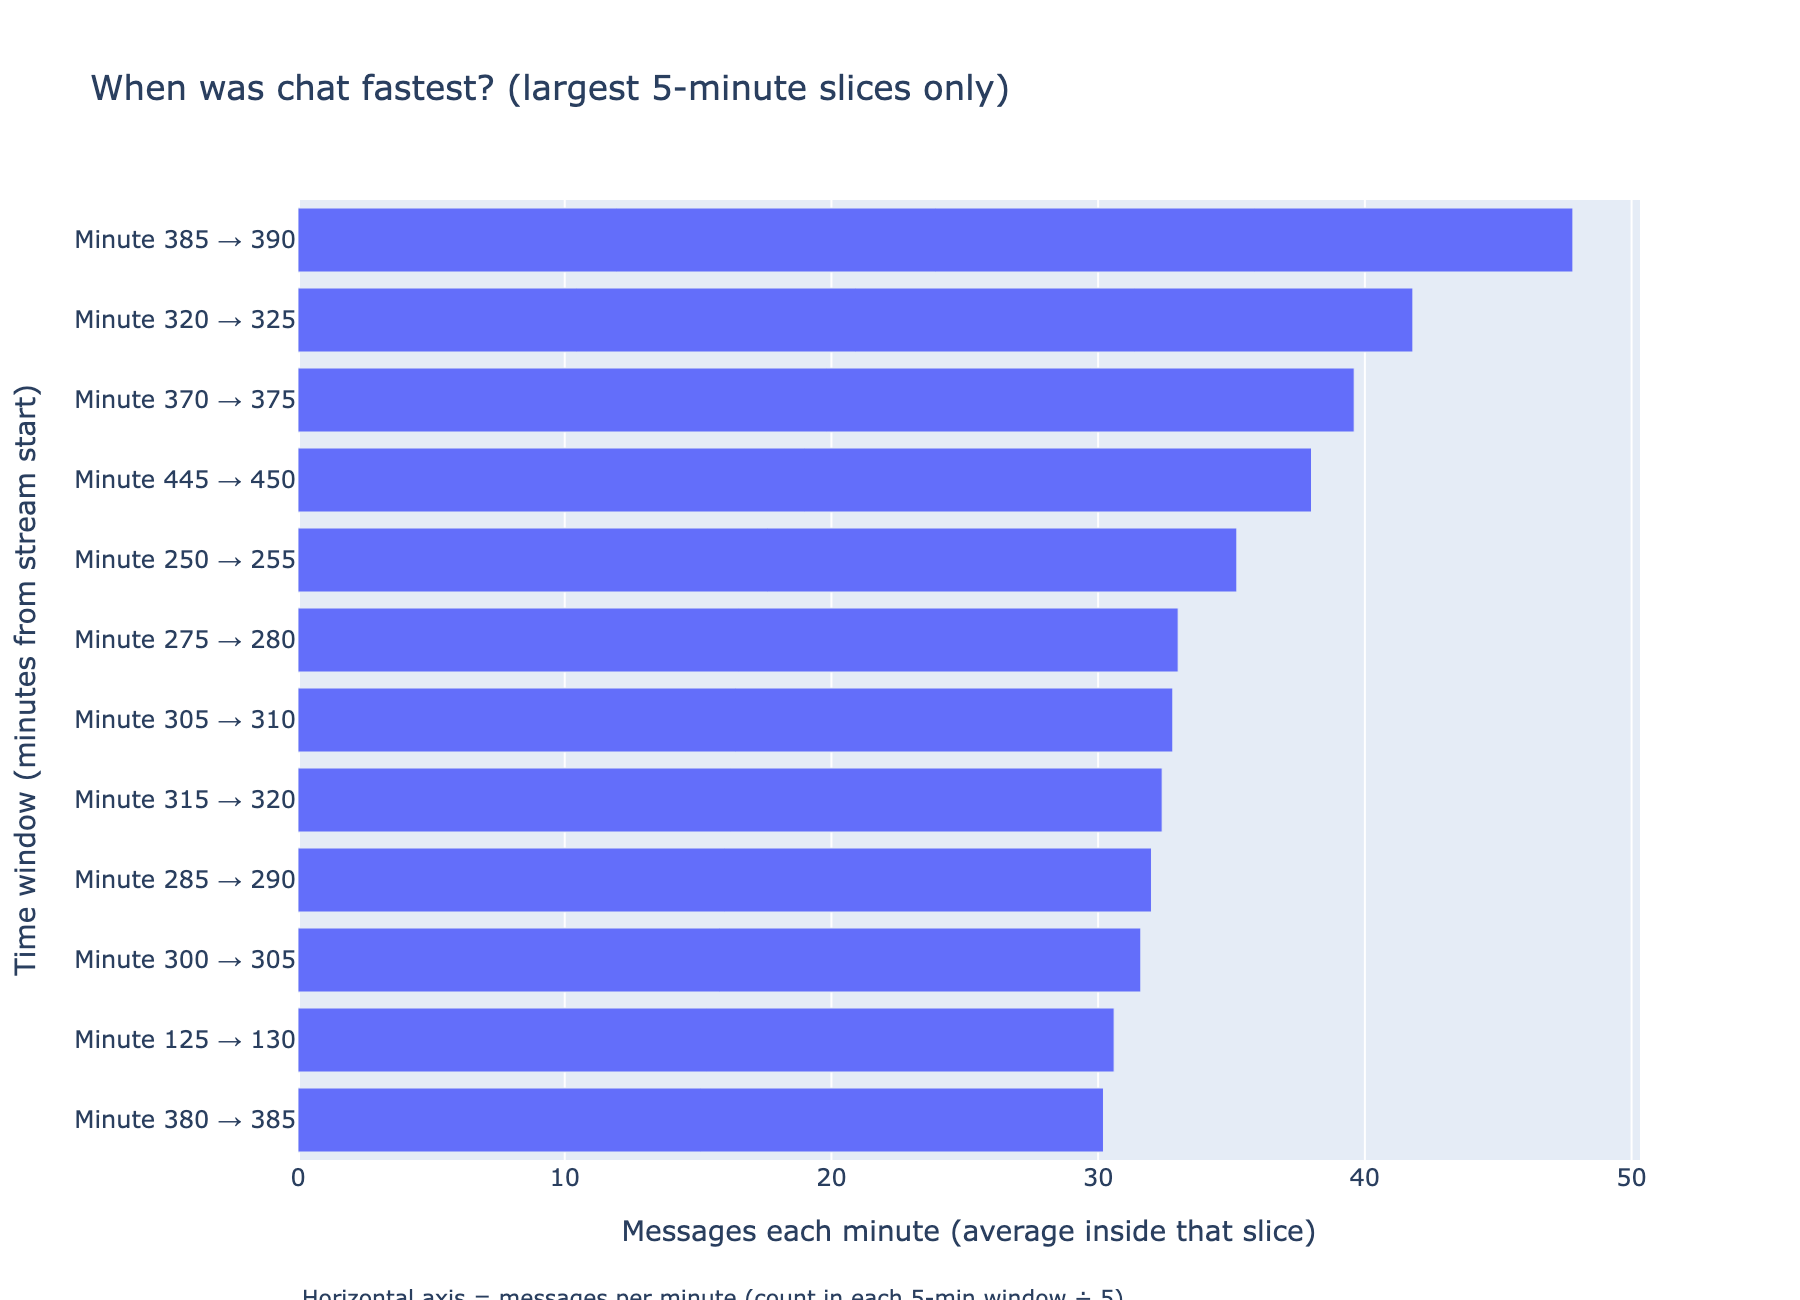

In [ ]:
# Chart 1: pick the 12 busiest 5-minute windows and display them as a horizontal bar chart
top_n = 12
top_bins = bin_df.nlargest(top_n, "messages_per_min").sort_values("messages_per_min")
top_bins["time_slice"] = top_bins["offset_min_bin_5"].apply(
    lambda m: f"Minute {int(m)} -> {int(m + 5)}"
)

fig1 = px.bar(
    top_bins,
    x="messages_per_min",
    y="time_slice",
    orientation="h",
    title="When was chat fastest? (largest 5-minute slices only)",
    labels={
        "messages_per_min": "Messages each minute (average inside that slice)",
        "time_slice": "Time window (minutes from stream start)",
    },
)
fig1.update_layout(
    yaxis={"categoryorder": "total ascending"},
    annotations=[
        dict(
            text="Horizontal axis = messages per minute (count in each 5-min window / 5).",
            xref="paper", yref="paper", x=0, y=-0.16,
            showarrow=False, xanchor="left", font=dict(size=11),
        )
    ],
    margin=dict(b=70),
)
fig1.write_image(IMAGES_DIR / "mp1_q1_volume_bursts.png", width=900, height=650, scale=2)
fig1.show()


**Chart 1: When was chat fastest? (horizontal bar, top 12 five-minute windows)**

The x-axis shows messages per minute (bin count divided by 5) for the twelve busiest 5-minute windows on the primary stream. The y-axis labels are minute ranges from stream start. Bars span about 30.2 to 47.8 messages per minute, with the longest bar at 47.8 (stream-wide median across all bins: 15.8).

Message rate on this stream is bursty rather than flat. The peak window at minute 385 reaches 47.8 messages per minute against a median of 15.8, roughly three times baseline. The chart argues that engagement is concentrated in short windows an editor could locate without rewatching the full broadcast. It does not support claims about specific in-game events because chat timestamps are not paired with a game event log, so it supports "look here" but not "this happened because X."


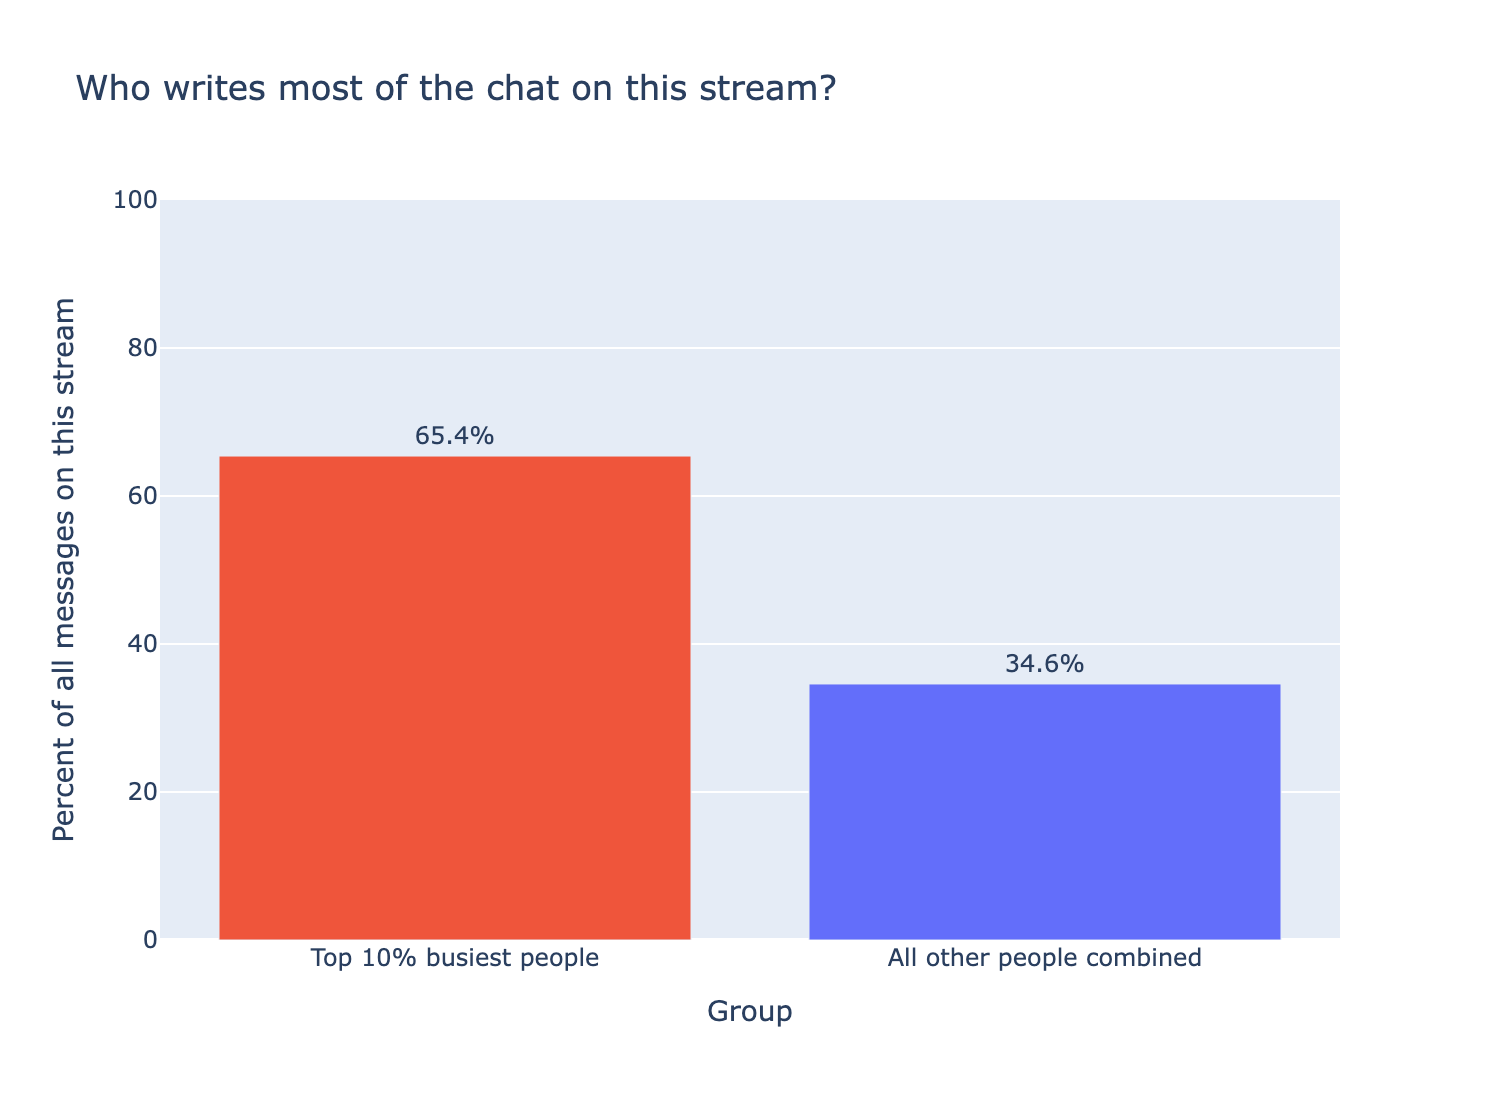

In [ ]:
# Chart 2: compare how much of total chat came from the top 10% vs everyone else
counts = primary_for_who["author_channel_id"].value_counts()
n_users = counts.size
total = counts.sum()
k_top = max(1, int(np.ceil(0.10 * n_users)))
pct_top = 100 * counts.head(k_top).sum() / total
who_df = pd.DataFrame(
    {
        "Group": ["Top 10% busiest people", "All other people combined"],
        "Percent of all messages": [pct_top, 100 - pct_top],
    }
)

fig2 = px.bar(
    who_df,
    x="Group",
    y="Percent of all messages",
    title="Who writes most of the chat on this stream?",
    color="Group",
    color_discrete_map={
        "Top 10% busiest people": "#EF553B",
        "All other people combined": "#636efa",
    },
    text="Percent of all messages",
)
fig2.update_traces(texttemplate="%{y:.1f}%", textposition="outside")
fig2.update_yaxes(
    title="Percent of all messages on this stream",
    range=[0, max(100, pct_top * 1.15)],
)
fig2.update_layout(showlegend=False)
fig2.write_image(IMAGES_DIR / "mp1_q2_author_concentration.png", width=750, height=550, scale=2)
fig2.show()


**Chart 2: Who writes most of the chat? (two bars)**

Compares the percent of all messages from the top 10% busiest accounts (65.4%) versus all other accounts combined (34.6%) on the primary stream.

On the primary stream, 7,971 messages come from 1,187 distinct authors. The busiest tenth of accounts (about 119 users) contribute 65.4% of all lines. Cumulative splits tighten quickly: 81.7% from the busiest quarter of accounts, and 91.9% from the busiest half. The chart argues that most of what appears on screen comes from a small minority of accounts, which means raw message volume is not a reliable proxy for how broadly an audience is engaged.


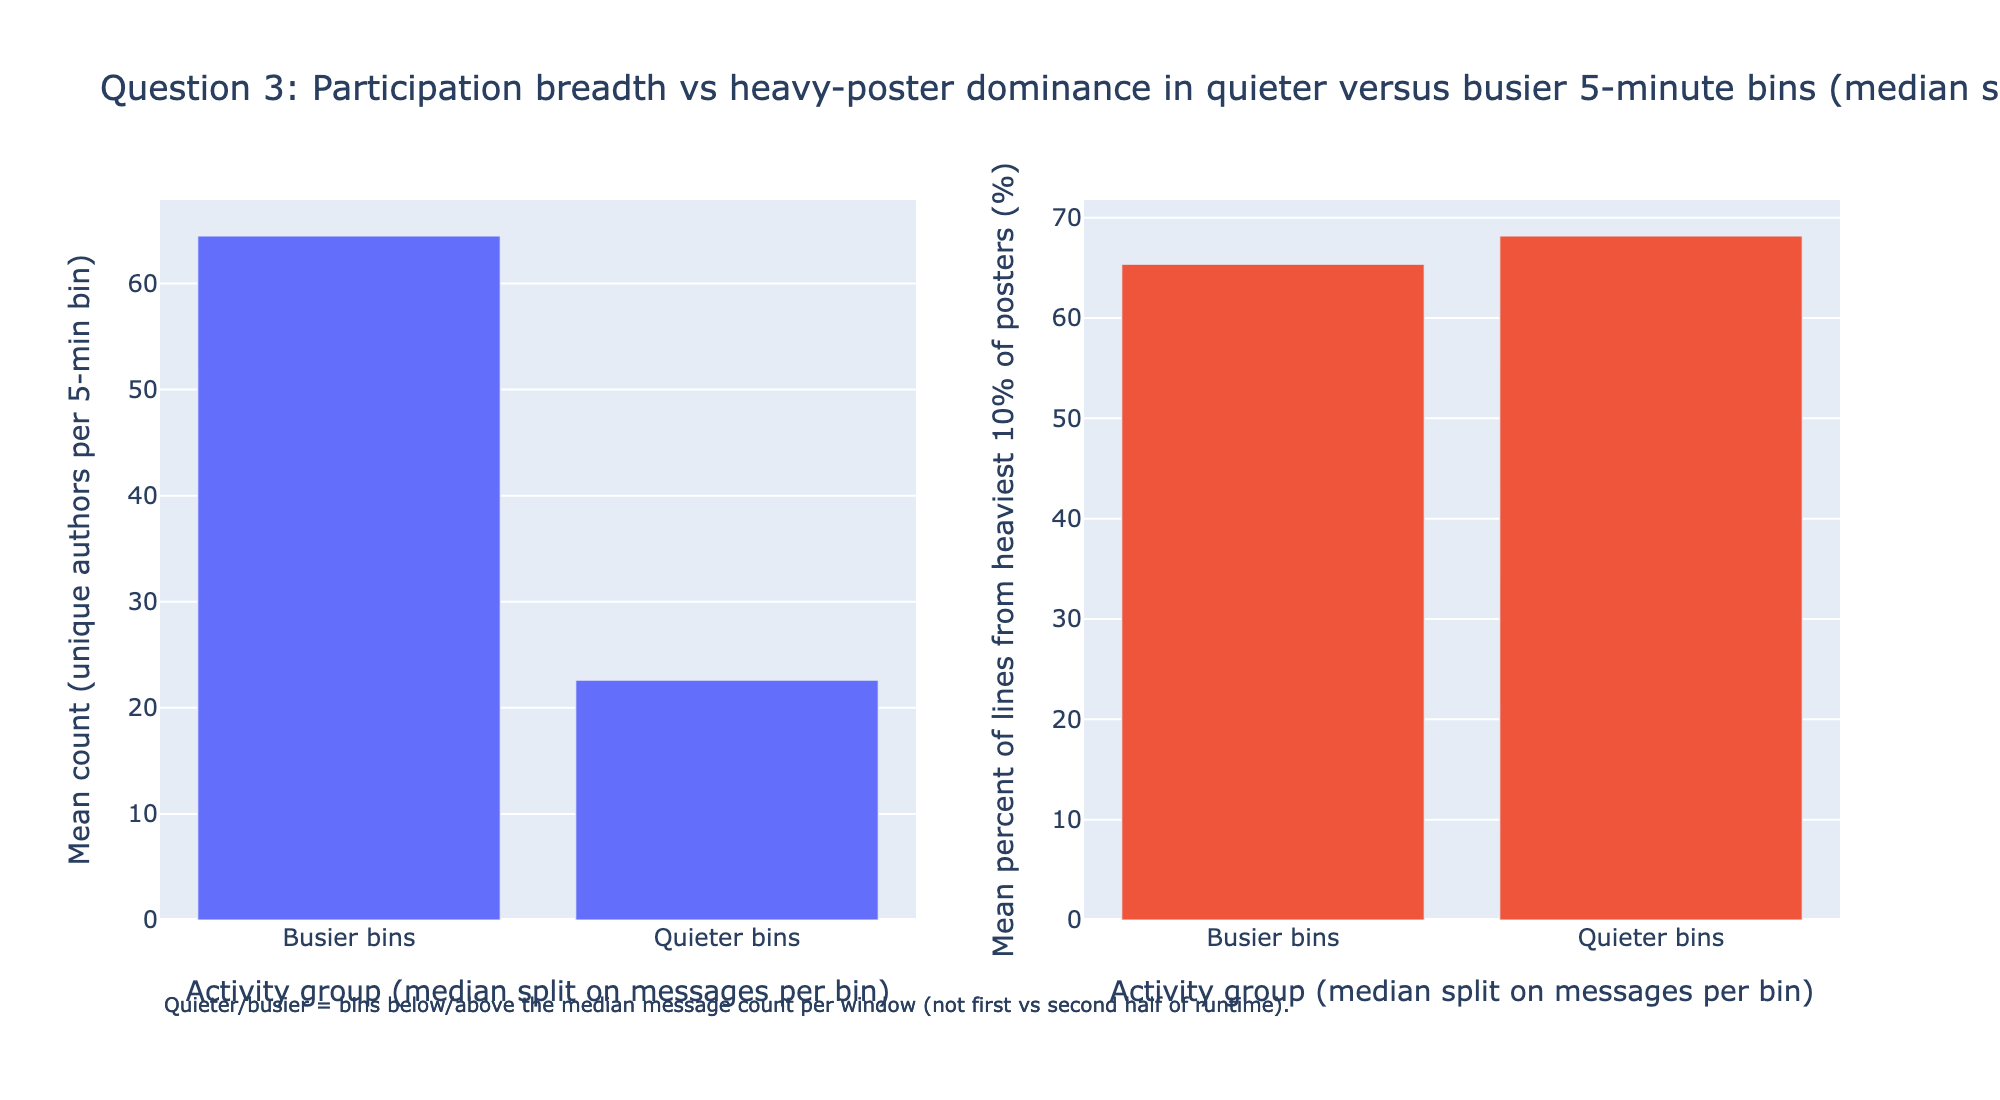

Saved PNGs: [PosixPath('images/mp1_q1_volume_bursts.png'), PosixPath('images/mp1_q2_author_concentration.png'), PosixPath('images/mp1_q3_participation_high_vs_low.png')]


In [ ]:
# Chart 3: compare busy vs quiet bins on two metrics (unique authors + heavy-poster share)
# Two side-by-side panels because the two y-axes have incompatible scales (counts vs percentages)
p3 = primary.copy()

# Identify the top 10% most active authors so we can track their share of messages per bin
author_totals = p3.groupby("author_channel_id").size().sort_values(ascending=False)
k10 = max(1, ceil(0.10 * author_totals.size))
heavy = set(author_totals.head(k10).index)
p3["from_heavy_posters"] = p3["author_channel_id"].isin(heavy)

# For each 5-minute window, calculate total messages, unique authors, and heavy-poster share
per_bin = (
    p3.groupby("offset_min_bin_5", as_index=False)
    .agg(
        messages_in_bin=("author_channel_id", "size"),
        different_people=("author_channel_id", pd.Series.nunique),
        pct_lines_from_heavy=("from_heavy_posters", "mean"),
    )
)

# Split bins into "Busier" and "Quieter" groups using the median message count as the cutoff
mid = per_bin["messages_in_bin"].median()
per_bin["kind"] = np.where(
    per_bin["messages_in_bin"] >= mid,
    "Busier bins",
    "Quieter bins",
)

# Average the metrics for each group
summary = (
    per_bin.groupby("kind", observed=True)
    .agg(
        avg_different_people=("different_people", "mean"),
        avg_pct_from_heavy=("pct_lines_from_heavy", "mean"),
    )
    .reset_index()
)
summary["pct_lines_heavy"] = 100 * summary["avg_pct_from_heavy"]
order = sorted(summary["kind"].tolist(), reverse=True)
s2 = summary.set_index("kind").loc[order].reset_index()

fig3 = make_subplots(
    rows=1,
    cols=2,
    subplot_titles=(
        "Mean unique authors per 5-minute bin",
        "Mean percent of lines from heaviest 10% of posters",
    ),
)
fig3.add_trace(
    go.Bar(x=s2["kind"], y=s2["avg_different_people"], marker_color="#636efa", showlegend=False),
    row=1, col=1,
)
fig3.add_trace(
    go.Bar(x=s2["kind"], y=s2["pct_lines_heavy"], marker_color="#EF553B", showlegend=False),
    row=1, col=2,
)
fig3.update_yaxes(title_text="Mean count (unique authors per 5-min bin)", row=1, col=1)
fig3.update_yaxes(title_text="Mean percent of lines from heaviest 10% of posters (%)", tickformat=".0f", row=1, col=2)
fig3.update_xaxes(title_text="Activity group (median split on messages per bin)", row=1, col=1)
fig3.update_xaxes(title_text="Activity group (median split on messages per bin)", row=1, col=2)
fig3.update_layout(
    title_text=(
        "Question 3: Participation breadth vs heavy-poster dominance in quieter "
        "versus busier 5-minute bins (median split, primary stream)"
    ),
    height=520, width=1000, margin=dict(b=90),
    annotations=[
        dict(
            text="Quieter/busier = bins below/above the median message count per window (not first vs second half of runtime).",
            xref="paper", yref="paper", x=0, y=-0.14,
            showarrow=False, xanchor="left", font=dict(size=10),
        )
    ],
)
fig3.write_image(IMAGES_DIR / "mp1_q3_participation_high_vs_low.png", width=1000, height=550, scale=2)
fig3.show()

# Clean up any leftover PNG files from an earlier version that had Q3 as two separate charts
for stale in ("mp1_q3a_unique_authors.png", "mp1_q3b_heavy_poster_share.png"):
    stale_path = IMAGES_DIR / stale
    if stale_path.exists():
        stale_path.unlink()
        print("Removed stale:", stale_path.name)

print("Saved PNGs:", sorted(IMAGES_DIR.glob("mp1_q*.png")))


**Chart 3: Do busy and quiet windows attract different kinds of chatters? (two-panel bar chart)**

Left panel: mean unique authors per 5-minute bin, about 22.6 in quieter windows versus 64.5 in busier ones (median split on messages per window). Right panel: mean percent of lines from the stream's heaviest 10% of posters, about 68.2% in quieter windows versus 65.4% in busier ones. Each panel has its own y-axis because counts and percentages are on incompatible scales.

Busier windows involve roughly three times as many unique speakers as quieter ones (64.5 vs 22.6 average unique authors). Heavy-poster dominance is slightly lower in busier windows, not higher. The chart argues that loud moments draw in a broader crowd rather than just the same frequent posters typing faster. Whether breadth or dominance matters more depends on the audience: editors care about breadth as a signal of moment importance, while engagement analysts care about dominance as a signal of audience composition.


**Supplementary vector copies (SVG):** Kaleido PNGs above are the graded static exports. Matching SVGs (same stems, from `Week 6/export_mp1_charts.py`):

- Chart 1: [mp1_q1_volume_bursts.svg](images/mp1_q1_volume_bursts.svg)
- Chart 2: [mp1_q2_author_concentration.svg](images/mp1_q2_author_concentration.svg)
- Chart 3 (two panels): [mp1_q3_participation_high_vs_low.svg](images/mp1_q3_participation_high_vs_low.svg)


---

## Section 4: Conclusions

**Most important finding:**

The single most important finding is the participation concentration: the busiest 10% of accounts produce 65.4% of all messages on this stream, with the busiest quarter producing 81.7% and the busiest half producing 91.9%. This matters most because it likely generalizes , heavy-tailed posting distributions show up in open chat venues broadly, regardless of whether the venue is busy or quiet, official or co-stream. It also has the clearest implication for downstream work: anyone treating raw message volume as a proxy for audience engagement is reading the activity of roughly a hundred accounts as if it were the activity of a thousand.

**What surprised you:**

Two things. First, the heavy-tailed concentration , the busiest 10% of accounts producing 65.4% of all messages , was sharper than I'd have guessed. I expected a skew, but not that the busiest tenth would carry roughly two-thirds of visible chat. Second, the overall volume was lower than I'd have expected for an official LEC broadcast. My read is that engagement is probably distributed across simultaneous venues: co-streamers on YouTube and Twitch broadcasting the same matches likely pull chat away from the official feed. YouTube may also not be where this audience defaults , Twitch is more gaming-native, and a follow-up on the same match on Twitch would test whether the lighter chat is a property of the official broadcast or of the platform.

**What you would investigate next:**

The most useful follow-up would be a side-by-side comparison of the same match on the official LEC broadcast versus a co-streamer's channel. Caedrel, a League of Legends personality who co-streams professional matches on his own channel, regularly draws 20,000+ concurrent viewers with active chat , substantially denser than what shows up in the official broadcast pull. Running this same analysis on a Caedrel VOD of the same match would test whether the participation patterns here (burst structure, top-10% concentration, breadth-vs-dominance shift) are properties of the broadcast or properties of the venue. I suspect the latter, but this data can't distinguish them.

**Limitations (factual):** Chat logs only , no in-game event timeline. No Super Chat rows in this export. Q1–Q3 describe **`vUmNslJBba0` only**, not the other three VODs in `chat_regular/`.

**Per-question wrap-up:**

> **Q1:** Message rate on the primary stream is bursty rather than flat. The busiest 5-minute window reaches 47.8 messages per minute against a stream-wide median of 15.8, roughly three times baseline. For an editor producing summary cuts, the burst windows locate when on the VOD to look without rewatching the full broadcast. They don't say what was happening on screen; there's no in-game event log paired with these chat timestamps, so the chart supports "look here" but not "this happened because X."
>
> **Q2:** The busiest 10% of accounts on this stream produce 65.4% of all messages, with cumulative shares of 81.7% from the busiest quarter and 91.9% from the busiest half. This is a heavy-tailed distribution that's likely a property of open chat venues broadly, not specific to this stream, but it's worth quantifying because it cautions against treating raw message volume as a proxy for audience reach. Most of what appears on screen comes from a small minority of accounts.
>
> **Q3:** Whether breadth or dominance matters more depends on the audience. Editors looking for moments worth capturing care more about breadth , busier windows averaging 64.5 unique authors versus 22.6 in quieter ones is a stronger signal of "many people reacted" than raw message count alone. Engagement analysts looking at audience composition care more about dominance, where the heavy-poster share is roughly 65% in busy bins and 68% in quiet ones. Both shift together in a way I didn't initially expect: louder windows draw broader participation in and slightly reduce heavy-poster share, so loud moments here are crowd-driven rather than just heavy posters typing faster.

---

**Draft conclusion:**

On the primary stream, message rates in 5-minute windows are uneven: the busiest slices approach about **48** messages per minute (**47.8**) while the median is roughly **16** (**15.8**), so bursts are short-lived rather than flat background chatter. Author activity is similarly skewed: the busiest tenth of accounts account for about **65%** of all chat lines on this VOD. After the Super Chat pivot, above-median bins involve far more unique authors than quieter bins, while the share of lines from the stream-wide heaviest tenth of posters remains high in both groups and is modestly lower in the busiest bins.


---

## Section 5: Process *(optional / added-on)*

> **Finding the data.** I searched YouTube for League of Legends livestreams and saw there were different regional leagues. I picked the North American one (LCS) at first, but it only had around 100,000 views per stream, while the European league (LEC) had closer to 300,000. I went with LEC because more viewers probably meant more active chatters, which would give me more data to work with. The collection script (`collect_vod_chat.py`) worked on the first try, so the actual pull wasn't the hard part. The hard part was deciding what to keep: usernames, message text, timestamps, message type, author IDs, and seconds-into-the-stream , what my three questions actually needed , without dragging in fields I wouldn't use.
>
> **Pivoting Q3.** My original Question 3 was about Super Chat rates , how often viewers send paid donation messages in busy versus quiet parts of the stream. When I actually looked at the data, there were zero Super Chats in any of the four VODs. I realized this was a property of official broadcasts: LEC is a sponsored channel, not a creator stream, so the donation feature isn't really used there. Co-streamers like Caedrel get Super Chats on their own channels, but the official LEC feed doesn't. So I pivoted Q3 to ask a different question the data could actually answer: how does the shape of participation change between busy and quiet periods , more unique speakers, or the same heavy posters typing faster?
>
> **Checking the data.** Before I considered the analysis done, I went back through and verified what was actually in the dataset. I found 143 rows with null message text, which I traced to messages that were just symbols or emoji art , people building pictures out of characters that didn't translate into readable text data. They don't affect my analysis because Q1 only needs timestamps and Q2 and Q3 only need author IDs, but it was worth checking rather than assuming. I also re-ran every number in my writeup against the actual files in the repo to make sure the analysis would reproduce for anyone who runs the notebook.
>
> **What I used Cursor for and what I overrode.** Cursor was useful for scaffolding , directory structure, file paths, image exports , but I overrode it on several judgment calls. The biggest one was sentiment analysis: Cursor built a sentiment layer that labeled each message with a category like joke, question, or hype. When I checked how it was actually applying those labels against the underlying messages, the calls were off often enough that I didn't trust the output as evidence of anything. Gaming chat uses too much community-specific jargon, regional slang, and ironic phrasing for a generic sentiment pass to capture reliably. I removed it from the analysis. The follow-up I'm planning is to hand-code one or two livestreams myself , label messages by category against my own reading , and then test whether Cursor can learn the patterns I tagged and produce sentiment readings that actually track how chat reacts over time. That would be a real next step, not something I'd fake with an off-the-shelf wordlist.
